# Buổi 2 — Xác suất và thống kê cho dự báo

**Một câu:** không ai biết chắc tương lai, nhưng ta có thể nói "thường khoảng bao nhiêu, hiếm khi quá bao nhiêu" — và
phải **kiểm xem lời hứa đó có giữ được không**.

Tình huống: hệ thống xe đạp công cộng Capital Bikeshare ở Washington D.C. muốn biết 17 giờ mai có bao nhiêu lượt thuê, để
chuẩn bị đủ xe. Sáu phần dưới là sáu công cụ để trả lời câu đó cho trung thực.

## 0. Dữ liệu

**Bộ dữ liệu Bike Sharing.** Nhóm tác giả ở Đại học Porto lấy nhật ký mọi lượt thuê của **Capital Bikeshare** — hệ thống xe đạp công cộng ở
Washington D.C., lấy xe ở trạm này, trả ở trạm khác — trong **hai năm 2011–2012**, đếm số lượt theo từng giờ và từng
ngày, rồi ghép thêm thời tiết và lịch nghỉ lễ. Hai bảng: `hour.csv` mỗi dòng là **một giờ** (17.379 dòng), `day.csv`
mỗi dòng là **một ngày** (731 dòng). Số lượt là của **cả hệ thống**, không phải một trạm.

Nguồn: Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894. Giấy phép CC BY 4.0.

| Cột | Nghĩa |
|---|---|
| `cnt` | **số lượt thuê** trong giờ (hoặc ngày) đó — thứ cần dự báo; bằng `casual` (khách vãng lai) + `registered` (hội viên) |
| `dteday`, `hr` | ngày, và giờ trong ngày (0–23; `day.csv` không có `hr`) |
| `yr` | năm: 0 là 2011, 1 là 2012 |
| `weekday`, `workingday` | thứ trong tuần (0 = Chủ nhật, 6 = thứ Bảy); ngày làm việc (1) hay nghỉ — cuối tuần, lễ (0) |
| `weathersit` | thời tiết: 1 quang đãng, 2 sương mù/nhiều mây, 3 mưa nhẹ/tuyết nhẹ, 4 mưa to/bão |
| `temp`, `hum` | nhiệt độ và độ ẩm, đã chia cho giá trị lớn nhất (41 °C, 100%) nên nằm trong 0–1 |

Ô dưới tải dữ liệu (280 KB) một lần rồi kiểm **sha256** — "dấu vân tay" tính từ nội dung tệp, sai một byte là ra chuỗi khác hẳn. Khớp nghĩa là bạn đang có đúng tệp mà mọi con số dưới đây được tính ra.

In [ ]:
import hashlib
import os
import urllib.request
from pathlib import Path

# tên bộ: (sha256, [nơi tải, thử lần lượt])
DU_LIEU = {
    "uci-bike-sharing": ("b70182d0d0508e9abbb79306ce5c0cec34869000f8220175ac83d11dbe845401", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/uci-bike-sharing/bike+sharing+dataset.zip",
        "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip",
    ]),
}
CACHE = Path(os.environ.get("KHOA_FORECASTING_CACHE") or Path.home() / ".cache" / "khoa-forecasting")


def sha256(tep: Path) -> str:
    h = hashlib.sha256()
    with open(tep, "rb") as f:
        for khoi in iter(lambda: f.read(1 << 20), b""):
            h.update(khoi)
    return h.hexdigest()


def lay(ten: str) -> Path:
    """Đường dẫn tệp đã kiểm sha256; chưa có thì tải về một lần."""
    sha, urls = DU_LIEU[ten]
    tep = CACHE / "sha256" / sha[:2] / sha
    if tep.is_file() and sha256(tep) == sha:
        return tep
    tep.parent.mkdir(parents=True, exist_ok=True)
    for url in urls:
        try:
            urllib.request.urlretrieve(url, tep)
            if sha256(tep) == sha:
                return tep
            print("sha256 không khớp:", url)
        except OSError as loi:
            print("tải lỗi:", url, loi)
    raise RuntimeError(f"không tải được {ten} khớp sha256")


for ten in DU_LIEU:
    print(f"{ten:<28} {lay(ten)}")

In [ ]:
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

with zipfile.ZipFile(lay("uci-bike-sharing")) as z:
    h = pd.read_csv(z.open("hour.csv"), parse_dates=["dteday"])
    d = pd.read_csv(z.open("day.csv"), parse_dates=["dteday"])
y = h["cnt"].to_numpy(float)
print(f"{len(h):,} giờ, {len(d)} ngày | TB mỗi ngày: 2011 = {d.loc[d.yr == 0, 'cnt'].mean():.0f}, 2012 = {d.loc[d.yr == 1, 'cnt'].mean():.0f}")
d.set_index("dteday")["cnt"].rolling(30, center=True).mean().plot(figsize=(9, 2.5), ylabel="lượt/ngày",
                                                                 title="Hè đông, đông vắng; 2012 đông hơn hẳn 2011")
plt.show()

## 1. Quantile trả lời "mức nào đủ cho 80% số lần?"

**Vấn đề.** Lượt thuê lúc 17h mai chưa biết trước — nó là một **biến ngẫu nhiên**. Ghi lại "mức nào hay gặp tới đâu"
bằng gì?

> **biến ngẫu nhiên** · *random variable*
>
> - **Là gì:** đại lượng chưa biết trước giá trị, chỉ biết giá trị nào hay gặp, giá trị nào hiếm.
> - **Ví dụ:** số lượt thuê lúc 17h mai: có thể 300, có thể 600, hiếm khi dưới 50.
> - **Để làm gì:** mọi thứ ta dự báo đều là biến ngẫu nhiên — nên dự báo tốt phải nói cả "chắc tới đâu".

> **histogram**
>
> - **Là gì:** biểu đồ cột: chia trục giá trị thành các khoảng, đếm có bao nhiêu số rơi vào mỗi khoảng.
> - **Ví dụ:** 9 số 2, 3, 5, 6, 8, 9, 12, 18, 36 → khoảng 0–9 có 6 số, 10–19 có 2 số, 20–29 có 0, 30–39 có 1.
> - **Để làm gì:** nhìn là thấy hình dạng phân phối: dồn ở đâu, lệch về bên nào, có số lạ không.
>
> 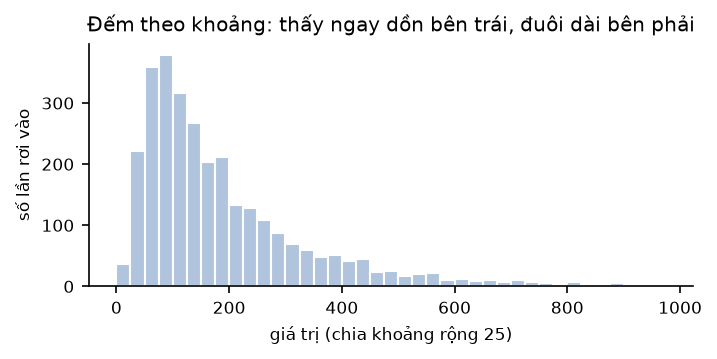

> **quantile, trung vị** · *quantile, median*
>
> - **Là gì:** quantile 0,8 là giá trị nhỏ nhất mà ít nhất 80% số liệu không vượt quá. Trung vị là quantile 0,5 — mốc chia đôi.
> - **Ví dụ:** 9 giờ xếp tăng 2, 3, 5, 6, **8**, 9, 12, **18**, 36: trung vị là số thứ 5 = 8; quantile 0,8 là số thứ 8 = 18.
> - **Để làm gì:** trả lời "cần chuẩn bị bao nhiêu xe để đủ cho 80% số giờ" — thứ trung bình không trả lời được.
>
> 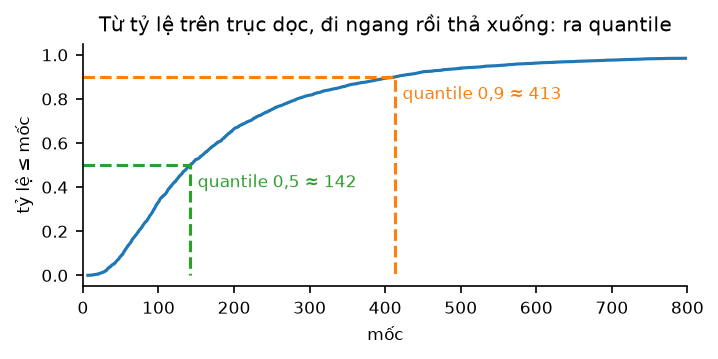

**Lý do.** Ghi lại bằng phân phối, rồi tóm nó bằng vài quantile. Tính tay quantile 0,8: xếp tăng, lấy vị trí 0,8 × số
lượng, làm tròn lên — 9 giờ thì vị trí 7,2 → số thứ 8 → **18**.

**Kết quả.**

In [ ]:
x9 = np.array([8, 2, 36, 5, 12, 3, 18, 6, 9])
print("quantile 0,8 — đếm tay:", np.quantile(x9, 0.8, method="inverted_cdf"), "| np.quantile mặc định:", round(np.quantile(x9, 0.8), 1))
print(f"dữ liệu thật: trung bình {y.mean():.0f}, trung vị {np.median(y):.0f}, quantile 0,9 {np.quantile(y, 0.9):.0f} lượt/giờ")
plt.figure(figsize=(9, 2.3))
plt.hist(y, bins=np.arange(0, 1000, 25), color="lightsteelblue")
plt.axvline(y.mean(), color="tab:orange", label="trung bình")
plt.axvline(np.median(y), color="tab:blue", ls="--", label="trung vị")
plt.legend(fontsize=8)
plt.title("Lệch phải: dồn bên trái, đuôi dài bên phải")
plt.show()

Máy mặc định **nội suy** giữa hai số kề nhau nên ra 14,4 thay vì 18; `method="inverted_cdf"` khớp cách đếm tay. Với
hàng nghìn số, hai cách gần như trùng. Lượt thuê **lệch phải**: vài giờ cao điểm rất đông kéo trung bình (189) lên cao
hơn trung vị (142).

**Bài học.** Trung vị là quantile 0,5. Dữ liệu lệch phải thì trung bình nằm bên phải trung vị.

## 2. Nên báo con số nào? Tuỳ bạn bị phạt thế nào khi sai

**Vấn đề.** 9 nhân viên lương 10 triệu, giám đốc 300 triệu: "lương trung bình 39 triệu" — đúng, nhưng không ai nhận mức
đó. Chỉ được báo **một** con số thì chọn trung bình, trung vị hay quantile?

> **phương sai, độ lệch chuẩn** · *variance, standard deviation*
>
> - **Là gì:** đo số liệu dao động quanh trung bình cỡ nào. Phương sai = tổng bình phương độ lệch chia $n-1$; độ lệch chuẩn $s$ = căn của phương sai, cùng đơn vị với dữ liệu.
> - **Ví dụ:** 2, 4, 6: trung bình 4, độ lệch −2, 0, 2 → phương sai (4 + 0 + 4)/2 = 4 → $s$ = 2.
> - **Để làm gì:** cho biết "lệch điển hình" bao nhiêu — nền của khoảng dự báo và khoảng tin cậy.
>
> 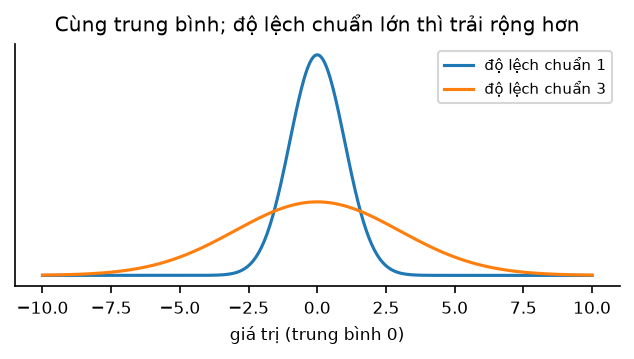

> **hệ số lệch** · *skewness*
>
> - **Là gì:** đo phân phối có đuôi dài về phía nào: dương là đuôi phải dài (vài số rất lớn), âm là đuôi trái dài.
> - **Ví dụ:** 1, 1, 2, 2, 3, 20 → dương, vì số 20 kéo đuôi phải.
> - **Để làm gì:** cảnh báo khi các công thức giả định hình chuông đối xứng (như ±1,96 × độ lệch chuẩn) sẽ sai.
>
> 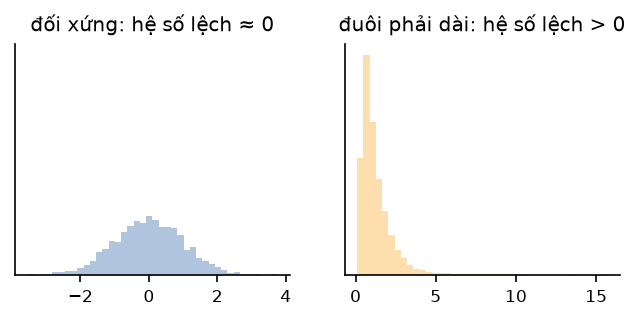

> **pinball loss** · *pinball loss, quantile loss*
>
> - **Là gì:** cách phạt một dự báo quantile mức τ: mỗi đơn vị thiếu phạt τ, mỗi đơn vị thừa phạt 1 − τ.
> - **Ví dụ:** τ = 0,8, thật 10, dự báo 8 → thiếu 2, phạt 0,8 × 2 = 1,6. Dự báo 12 → thừa 2, phạt 0,2 × 2 = 0,4.
> - **Để làm gì:** thước đo đúng cho dự báo quantile — và cho bài toán thiếu đắt hơn thừa.
>
> 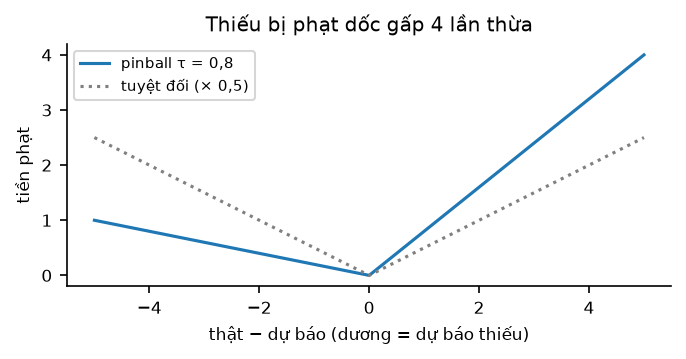

**Lý do.** Mỗi cách phạt có một con số tốt nhất riêng:

- Phạt **tuyệt đối** |thật − dự báo| → tốt nhất là **trung vị** (hai phe trên/dưới cân nhau).
- Phạt **bình phương** (thật − dự báo)² → tốt nhất là **trung bình** (số ở xa bị phạt nặng, kéo con số về phía nó).
- Phạt **pinball** mức τ → tốt nhất là **quantile τ** (τ = 0,8: thiếu đắt gấp 4 lần thừa).

**Kết quả.** Báo cùng một con số $c$ cho 9 giờ trên, tính phạt trung bình:

In [ ]:
def pinball(y, c, tau):
    sai = np.asarray(y, float) - c
    return float(np.where(sai >= 0, tau * sai, (tau - 1) * sai).mean())


print(f"trung bình {x9.mean():.0f}, độ lệch chuẩn s = {x9.std(ddof=1):.2f} (ddof=1: chia n − 1)")
print(pd.DataFrame({c: {"tuyệt đối": np.abs(x9 - c).mean(), "bình phương": ((x9 - c) ** 2).mean(), "pinball 0,8": pinball(x9, c, 0.8)}
                    for c in (8, 11, 18)}).T.rename_axis("c (trung vị / trung bình / quantile 0,8)").round(2))

Mỗi cột thấp nhất ở một dòng khác: tuyệt đối ở trung vị (8), bình phương ở trung bình (11), pinball ở quantile 0,8
(18). Trên cả 17.379 giờ thật cũng vậy: thử mọi $c$, đáy của ba đường rơi đúng trung bình, trung vị, quantile.

**Bài học.** Trước khi hỏi "báo con số nào", hỏi "sai thì bị phạt thế nào".

## 3. Khoảng "95%" chỉ đáng tin khi đo tỷ lệ phủ trên dữ liệu chưa dùng

**Vấn đề.** Khoảng "17h mai 65–604 lượt, 95%" hứa rằng 100 lần nói như vậy thì khoảng 95 lần đúng. Lời hứa có giữ được
không?

> **phân phối chuẩn** · *normal distribution, Gaussian*
>
> - **Là gì:** đường cong hình chuông, đối xứng quanh trung bình; 95% giá trị nằm trong trung bình ± 1,96 độ lệch chuẩn.
> - **Ví dụ:** trung bình 100, độ lệch chuẩn 10 → 95% giá trị trong 100 ± 19,6, tức 80,4–119,6.
> - **Để làm gì:** là nguồn gốc con số 1,96 — chỉ dùng được khi dữ liệu gần hình chuông.
>
> 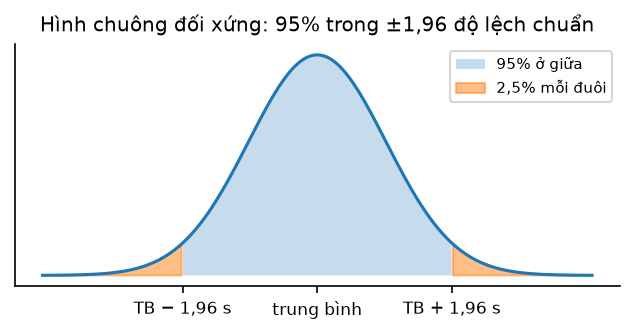

> **tỷ lệ phủ** · *coverage*
>
> - **Là gì:** tỷ lệ số lần giá trị thật rơi vào khoảng đã báo.
> - **Ví dụ:** báo 100 khoảng "95%", thật rơi vào 64 lần → tỷ lệ phủ 64%, lời hứa bị vỡ.
> - **Để làm gì:** cách duy nhất kiểm một khoảng có trung thực không. Đếm riêng hai đuôi để biết khoảng lệch về phía nào.
>
> 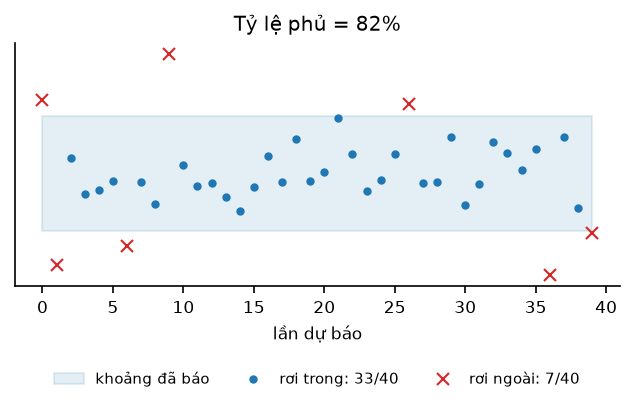

> **trong mẫu / ngoài mẫu** · *in-sample / out-of-sample*
>
> - **Là gì:** trong mẫu: đo trên dữ liệu đã dùng để dựng; ngoài mẫu: đo trên dữ liệu chưa dùng.
> - **Ví dụ:** dựng khoảng từ năm 2011; chấm trên 2011 là trong mẫu, chấm trên 2012 là ngoài mẫu.
> - **Để làm gì:** chỉ con số ngoài mẫu mới nói được chuyện sẽ xảy ra khi dùng thật.

> **xu hướng** · *trend*
>
> - **Là gì:** hướng đi lâu dài của chuỗi — tăng dần, giảm dần hay đi ngang.
> - **Ví dụ:** lượt thuê trung bình mỗi giờ từ 144 (2011) lên 235 (2012).
> - **Để làm gì:** khoảng dựng từ quá khứ mà bỏ qua xu hướng sẽ vỡ khi tương lai đi lên (hoặc xuống).

**Lý do.** Công thức quen thuộc **trung bình ± 1,96 × độ lệch chuẩn** chỉ đúng với hình chuông. Lượt thuê không hình chuông — nó lệch phải — nên công thức này cho cận dưới quá thấp
(có khi âm). Sửa: lấy thẳng **quantile 0,025 và 0,975** của lịch sử. Nhưng không cách nào cứu được nếu tương lai khác quá
khứ.

**Kết quả.** Mỗi giờ trong ngày dựng một khoảng từ năm 2011, rồi đếm riêng hai đuôi:

In [ ]:
cach = {"±1,96s": lambda x: (x.mean() - 1.96 * x.std(ddof=1), x.mean() + 1.96 * x.std(ddof=1)),
        "quantile": lambda x: tuple(np.quantile(x, [0.025, 0.975]))}
n11, n12h = h[h.yr == 0], h[h.yr == 1]
hang = []
for ten, f in cach.items():
    k = pd.DataFrame([(g, *f(nhom["cnt"])) for g, nhom in n11.groupby("hr")], columns=["hr", "lo", "hi"])
    for cham, du in [("2011 (đã dùng)", n11), ("2012 (chưa dùng)", n12h)]:
        m = du.merge(k, on="hr")
        hang.append({"cách": ten, "chấm trên": cham, "phủ": np.mean((m.cnt >= m.lo) & (m.cnt <= m.hi)),
                     "rơi dưới": np.mean(m.cnt < m.lo), "vượt trên": np.mean(m.cnt > m.hi)})
print(pd.DataFrame(hang).to_string(index=False, float_format="{:.1%}".format))

Trên 2011, hai cách đều phủ khoảng 95%, nhưng ±1,96s lệch đuôi: gần như không bao giờ rơi dưới, vượt trên quá nhiều.
Quantile cân lại hai đuôi. Trên 2012 cả hai **vỡ** (khoảng 70%): năm 2012 đông hơn hẳn (trung bình mỗi giờ 144 → 235) —
cả chuỗi dời lên, gọi là **dịch mức**.

**Bài học.** Chấm khoảng trên dữ liệu **chưa dùng** và báo **riêng từng đuôi**. Quantile sửa được hình dạng, không sửa
được tương lai khác quá khứ.

## 4. Tương quan chỉ đo quan hệ thẳng, và không phải nhân quả

**Vấn đề.** Trời ấm thì đông khách hơn? Cần một con số đo "hai đại lượng cùng lên cùng xuống tới đâu".

> **tương quan, hệ số r** · *correlation coefficient*
>
> - **Là gì:** con số từ −1 đến 1 đo hai đại lượng cùng tăng giảm theo đường thẳng tới đâu.
> - **Ví dụ:** 1, 2, 3 và 2, 4, 6 → $r$ = 1 (cùng tăng hoàn hảo); 1, 2, 3 và 6, 4, 2 → $r$ = −1.
> - **Để làm gì:** tìm biến giúp dự báo: nhiệt độ có $r$ dương với lượt thuê thì dự báo nhiệt độ giúp dự báo lượt thuê.
>
> 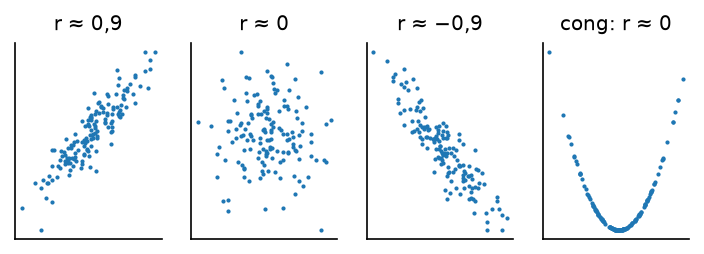

> **tự tương quan** · *autocorrelation*
>
> - **Là gì:** tương quan của một chuỗi với chính nó lùi $k$ bước.
> - **Ví dụ:** chuỗi 1, 3, 1, 3 lên xuống xen kẽ → tự tương quan trễ 1 là −0,75.
> - **Để làm gì:** đo "giờ này có giống giờ trước không" — cao thì quá khứ gần giúp dự báo tốt, nhưng dữ liệu ít thông tin mới.
>
> 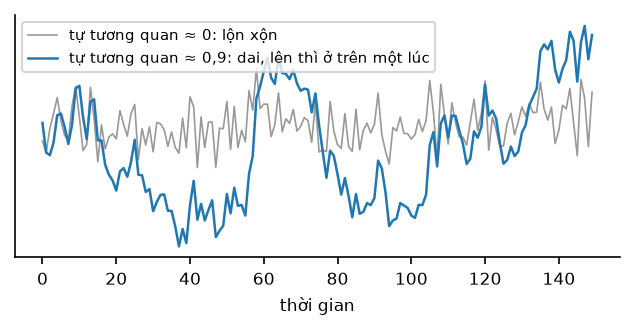

**Lý do.** Cách tính $r$: với mỗi ngày, xem nhiệt độ và lượt thuê cao hay thấp **hơn bình thường**; nhân hai độ lệch
(cùng phía → dương), cộng lại, chia cho một số chuẩn hoá. Hai cái bẫy: $r$ chỉ đo quan hệ **đường
thẳng**; và $r$ cao có thể do một **biến gây nhiễu** tác động lên cả hai (kem và đuối nước cùng tăng vì trời nóng).

**Kết quả.**

In [ ]:
xu = np.array([-2, -1, 0, 1, 2])
print("y = x² (liên quan hoàn toàn, nhưng cong): r =", round(np.corrcoef(xu, xu**2)[0, 1], 3))
g17 = h[h.hr == 17]
print(f"giờ trong ngày × lượt thuê: r = {np.corrcoef(h.hr, h.cnt)[0, 1]:.2f}  ← quan hệ rất mạnh nhưng cong")
print(f"nhiệt độ × lượt thuê: mọi giờ r = {np.corrcoef(h.temp, h.cnt)[0, 1]:.2f}, chỉ lúc 17h r = {np.corrcoef(g17.temp, g17.cnt)[0, 1]:.2f}")
print(f"độ ẩm × lượt thuê  : mọi giờ r = {np.corrcoef(h.hum, h.cnt)[0, 1]:.2f}, chỉ lúc 17h r = {np.corrcoef(g17.hum, g17.cnt)[0, 1]:.2f}")
dc = y - y.mean()
print(f"tự tương quan (giờ này với giờ trước): {(dc[1:] * dc[:-1]).sum() / (dc**2).sum():.2f}")

Giờ trong ngày quyết định lượt thuê rất mạnh (đêm gần 0, đỉnh 8h và 17h) mà $r$ chỉ 0,39 — vì quan hệ cong. Giữ cố
định giờ (chỉ xét 17h) thì $r$ của độ ẩm yếu đi: phần lớn quan hệ "ẩm ↔ vắng" là vì cả hai cùng là "ban đêm" — giờ trong
ngày là biến gây nhiễu. Dòng cuối là **tự tương quan**: tương quan của chuỗi với chính nó lùi một bước — 0,84, giờ liền
nhau gần như "biết" nhau (phần 6 cần con số này).

**Bài học.** Vẽ trước khi tin $r$; $r$ gần 0 vẫn có thể có quan hệ cong; $r$ cao chưa phải nhân quả — nhưng biến không
gây ra $y$ vẫn có thể giúp dự báo $y$.

## 5. Kiểm định hỏi: nếu không có gì đặc biệt, kết quả này hiếm cỡ nào?

**Vấn đề.** Năm 2012 ngày làm việc trung bình hơn ngày nghỉ 456 lượt. Khác biệt thật hay do may?

> **kiểm định, giả thuyết không H0** · *hypothesis test, null hypothesis*
>
> - **Là gì:** kiểm định xem dữ liệu có đủ bằng chứng bác bỏ một giả định mặc định "không có gì đặc biệt" — gọi là $H_0$.
> - **Ví dụ:** $H_0$: "đồng xu cân đối"; "nhãn ngày làm việc/nghỉ không liên quan tới lượt thuê".
> - **Để làm gì:** tránh kết luận vội từ một khác biệt có thể chỉ do may.
>
> 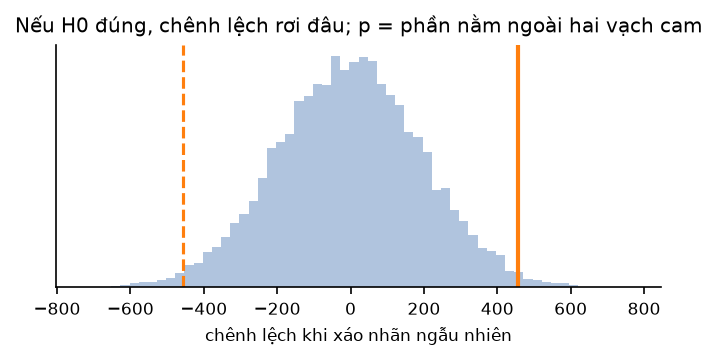

> **p-value**
>
> - **Là gì:** nếu $H_0$ đúng, xác suất gặp kết quả lệch cỡ này hoặc hơn.
> - **Ví dụ:** đồng xu cân đối mà tung 10 lần được ≥ 9 ngửa: p = 11/1.024 ≈ 0,011.
> - **Để làm gì:** p nhỏ nghĩa là "nếu không có gì đặc biệt thì chuyện này rất hiếm" → có lý do để tin có gì đó thật.

> **mức ý nghĩa α** · *significance level*
>
> - **Là gì:** ngưỡng chọn **trước** khi xem dữ liệu; p nhỏ hơn nó thì bác bỏ $H_0$. Hay dùng 0,05.
> - **Ví dụ:** p = 0,011 < 0,05 → bác bỏ "đồng xu cân đối"; p = 0,17 → không bác bỏ.
> - **Để làm gì:** chọn trước để không bị cám dỗ dời ngưỡng cho vừa kết quả mình muốn.

> **seed** · *random seed*
>
> - **Là gì:** con số khởi đầu của bộ sinh số ngẫu nhiên; cùng seed thì ra cùng dãy số.
> - **Ví dụ:** `np.random.default_rng(2026)` chạy hai lần cho đúng cùng các lần xáo nhãn.
> - **Để làm gì:** làm kết quả có yếu tố ngẫu nhiên lặp lại được — người khác chạy lại ra đúng con số của bạn.

**Lý do.** Tung đồng xu 10 lần được 9 ngửa: nếu đồng xu cân đối, chuyện đó hiếm cỡ p = 0,011 < 0,05 → bác bỏ "cân
đối". Với hai nhóm ngày: $H_0$ là "nhãn làm việc/nghỉ chẳng liên quan"; nếu vậy, **xáo nhãn ngẫu nhiên** cũng ra chênh lệch cỡ thật. p =
tỷ lệ lần xáo lệch bằng hoặc hơn chênh thật (**kiểm định hoán vị**).

**Kết quả.**

In [ ]:
def hoan_vi(yy, nhom, so_lan=9999, seed=2026):
    yy, nhom = np.asarray(yy, float), np.asarray(nhom, bool)
    that = yy[nhom].mean() - yy[~nhom].mean()
    rng = np.random.default_rng(seed)
    k = 0
    for _ in range(so_lan):
        p_ = rng.permutation(nhom)                                  # xáo nhãn, giữ nguyên các con số
        k += abs(yy[p_].mean() - yy[~p_].mean()) >= abs(that)       # lệch về phía nào cũng tính
    return that, (k + 1) / (so_lan + 1)


n12 = d[d.yr == 1]
ct = n12[n12.weekday.isin([0, 6])]
for ten, yy, nhom in [("làm việc − nghỉ", n12.cnt, n12.workingday == 1), ("thứ Bảy − Chủ nhật", ct.cnt, ct.weekday == 6)]:
    that, p = hoan_vi(yy, nhom)
    print(f"{ten:<20} {nhom.sum()} và {(~nhom).sum()} ngày | chênh {that:+.0f} lượt/ngày | p = {p:.3f}")

Làm việc − nghỉ: p = 0,025 < 0,05 → khác biệt thật. Thứ Bảy − Chủ nhật chênh **lớn hơn** (695) mà p = 0,077 →
không bác bỏ: mỗi nhóm chỉ khoảng 50 ngày nên trung bình dao động mạnh. Ba câu hay nói sai: không bác bỏ ≠ chứng minh
$H_0$ đúng; p không phải "xác suất $H_0$ đúng"; "có ý nghĩa thống kê" ≠ "khác biệt lớn".

**Bài học.** p nhỏ hơn ngưỡng thì bác bỏ; không bác bỏ thì chưa kết luận được gì. Xáo nhãn giả định các ngày độc lập —
ngày liền nhau giống nhau thì p thật lớn hơn con số tính được.

## 6. Dữ liệu theo thời gian cần block bootstrap, không phải rút từng điểm

**Vấn đề.** Trung bình lượt thuê năm 2012 chắc chắn tới đâu? Cần một khoảng tin cậy — khác khoảng dự báo ở phần 3 (cho
một giá trị sắp tới).

> **khoảng tin cậy** · *confidence interval*
>
> - **Là gì:** khoảng cho một con số **cố định** chưa biết (như trung bình thật), không phải cho một giá trị sắp tới.
> - **Ví dụ:** "trung bình thật mỗi giờ nằm trong 230–240 lượt, tin cậy 95%" (số minh hoạ).
> - **Để làm gì:** cho biết con số tóm tắt của mình chắc chắn tới đâu; càng nhiều dữ liệu độc lập, khoảng càng hẹp.

> **mẫu / tổng thể** · *sample / population*
>
> - **Là gì:** mẫu là số liệu đang có trong tay; tổng thể là mọi giá trị có thể đo nếu đo mãi.
> - **Ví dụ:** 100 giờ đang có là mẫu; mọi giờ của hệ thống là tổng thể; "trung bình thật" là trung bình của tổng thể.
> - **Để làm gì:** ta chỉ thấy mẫu nhưng muốn nói về tổng thể — thống kê là cầu nối giữa hai thứ đó.

> **i.i.d.** · *independent and identically distributed*
>
> - **Là gì:** các quan sát **độc lập** (biết lần này không giúp đoán lần kia) và **cùng phân phối** (cùng một "hộp").
> - **Ví dụ:** các lần tung một xúc xắc là i.i.d.; lượt thuê giờ liền nhau thì **không** (giờ này đông thì giờ sau cũng đông).
> - **Để làm gì:** nhiều công thức (và bootstrap thường) giả định i.i.d.; dữ liệu thời gian gần như luôn vi phạm.

> **định lý giới hạn trung tâm (CLT)** · *central limit theorem*
>
> - **Là gì:** trung bình của nhiều số i.i.d. có phân phối gần hình chuông, dao động theo $\sigma/\sqrt{n}$ ($\sigma$ là độ dao động của từng số).
> - **Ví dụ:** trung bình 100 giờ rút ngẫu nhiên dao động khoảng 181 / √100 ≈ 18 lượt; 400 giờ thì ≈ 9 lượt.
> - **Để làm gì:** giải thích vì sao thêm dữ liệu làm khoảng tin cậy hẹp lại — nhưng chậm: gấp 4 dữ liệu chỉ hẹp một nửa.
>
> 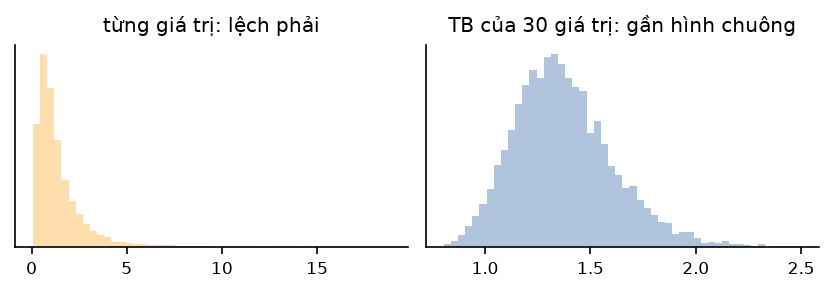

> **tự hồi quy, AR(1)** · *autoregressive model of order 1*
>
> - **Là gì:** giá trị mới = ρ × giá trị cũ + một cú hích ngẫu nhiên mới. ρ càng gần 1, chuỗi càng "dai".
> - **Ví dụ:** ρ = 0,7, bước trước 10, cú hích 0,5 → bước này 0,7 × 10 + 0,5 = 7,5.
> - **Để làm gì:** mô hình đơn giản nhất cho chuỗi "nhớ bước trước" — dùng để mô phỏng và kiểm phương pháp.

> **cỡ mẫu hiệu dụng** · *effective sample size*
>
> - **Là gì:** số quan sát độc lập mà một chuỗi tự tương quan "đáng giá"; với AR(1) ≈ $n(1-\rho)/(1+\rho)$.
> - **Ví dụ:** 200 điểm, ρ = 0,7 → 200 × 0,3 / 1,7 ≈ 35 điểm độc lập.
> - **Để làm gì:** cho biết khoảng tin cậy tính như i.i.d. hẹp quá bao nhiêu: ở đây phải rộng gấp √(200/35) ≈ 2,4 lần.

> **bootstrap, block bootstrap**
>
> - **Là gì:** bootstrap: rút lại có hoàn lại từ chính dữ liệu, tính lại con số, lặp nghìn lần để xem nó dao động cỡ nào. Block bootstrap rút cả khúc liền nhau.
> - **Ví dụ:** từ 5, 7, 9 rút ra 7, 7, 5; bản block với khối 2 từ 12, 15, 11, 30, 14 có thể rút (30, 14), (15, 11), (12, 15).
> - **Để làm gì:** dựng khoảng tin cậy không cần công thức; bản block giữ được sự phụ thuộc giữa các thời điểm liền nhau.
>
> 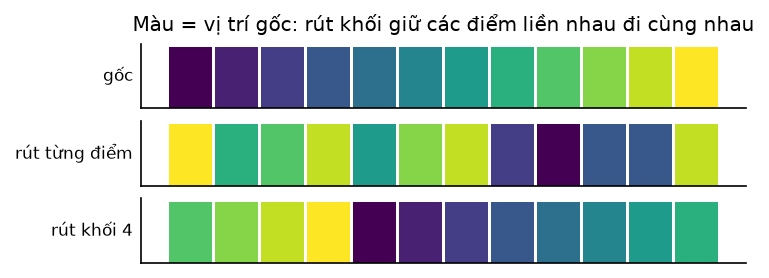

**Lý do.** Bootstrap rút lại từ chính mẫu nghìn lần rồi lấy quantile 0,025 và 0,975 của các trung bình. Nhưng giờ liền
nhau "biết" nhau (tự tương quan 0,84): 200 giờ liền nhau chỉ đáng giá như vài chục giờ độc lập. Rút **từng điểm** xé rời
chúng → khoảng quá hẹp. **Block bootstrap** rút cả **khối** điểm liền nhau để giữ sự phụ thuộc.

**Kết quả.** Mô phỏng 300 chuỗi AR(1) có trung bình thật bằng 0 và ρ = 0,7; đếm bao nhiêu khoảng "95%" chứa được 0:

In [ ]:
def ar1(n, rho, rng):
    e = rng.normal(size=n)
    x = np.empty(n)
    x[0] = e[0] / np.sqrt(1 - rho**2)
    for t in range(1, n):
        x[t] = rho * x[t - 1] + e[t]
    return x


def khoang_tin_cay(x, khoi, so_lan=999, seed=0):
    rng, n = np.random.default_rng(seed), x.size
    if khoi <= 1:
        cs = rng.integers(0, n, size=(so_lan, n))                                  # rút từng điểm
    else:
        bat_dau = rng.integers(0, n - khoi + 1, size=(so_lan, int(np.ceil(n / khoi))))
        cs = (bat_dau[:, :, None] + np.arange(khoi)).reshape(so_lan, -1)[:, :n]    # rút khối liền nhau
    return np.quantile(x[cs].mean(axis=1), [0.025, 0.975])


rng = np.random.default_rng(2026)
chuoi = [ar1(200, 0.7, rng) for _ in range(300)]
for khoi in (1, 3, 6, 10, 20, 40):
    trung = np.mean([lo <= 0 <= hi for i, x in enumerate(chuoi) for lo, hi in [khoang_tin_cay(x, khoi, seed=2026 + i)]])
    print(f"khối {khoi:>2}: {trung:.1%} khoảng chứa trung bình thật")

Rút từng điểm (khối 1) hứa 95% mà chỉ giữ được khoảng **60%**. Khối dài dần thì tốt lên, đỉnh gần 90% ở khối 10–20,
rồi tụt lại ở khối 40 (khối quá dài thì hai đầu chuỗi hiếm khi vào mẫu, các mẫu lại giống nhau, khoảng lại hẹp).

**Bài học.** Dữ liệu tự tương quan chứa ít thông tin hơn số điểm của nó; rút từng điểm cho khoảng quá tự tin. Rút khối
sửa phần lớn, nhưng độ dài khối là quyết định nhạy — luôn thử vài độ dài.

## 7. Bài tập về nhà — đáp số

**Bài 1 — Khoảng tin cậy cho lượt thuê theo ngày 2012**, rút từng ngày và rút khối 7, 14, 30 ngày:

In [ ]:
ngay12 = n12.cnt.to_numpy(float)
for khoi in (1, 7, 14, 30):
    lo, hi = khoang_tin_cay(ngay12, khoi, so_lan=9999, seed=2026)
    print(f"khối {khoi:>2}: [{lo:,.0f}; {hi:,.0f}]  rộng {hi - lo:,.0f}")

Khối càng dài, khoảng càng rộng — rút từng ngày tự tin quá mức. Báo quản lý khoảng của khối dài, kèm cảnh báo rằng
độ rộng còn phụ thuộc độ dài khối vì chuỗi có mùa vụ và tăng dần trong năm.

**Bài 2 — Ngày mưa** (`weathersit` ≥ 3) so với ngày còn lại năm 2012:

In [ ]:
mua = n12.weathersit >= 3
that, p = hoan_vi(n12.cnt, mua)
print(f"{mua.sum()} ngày mưa | chênh {that:+,.0f} lượt/ngày | p = {p:.4f}")

Không lần xáo nào lệch cỡ đó → bác bỏ $H_0$: ngày mưa vắng khách hơn thật. Nhưng chỉ có 6 ngày mưa, nên con số
chênh lệch chính xác tới đâu thì không chắc; và ngày liền nhau giống nhau nên p thật lớn hơn một chút.

## Tự kiểm

- [ ] Tính tay quantile 0,8 và trung vị của 5–10 số; nói vì sao máy có thể ra số khác.
- [ ] Nói được cách phạt nào ứng với trung bình, trung vị, quantile.
- [ ] Giải thích vì sao khoảng dựng từ 2011 chỉ phủ khoảng 70% năm 2012, và vì sao phải đếm riêng hai đuôi.
- [ ] Đọc đúng một p-value: nêu $H_0$, so với 0,05, không nói "chứng minh".
- [ ] Giải thích vì sao rút từng điểm chỉ phủ khoảng 60% trên chuỗi tự tương quan.